**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/tcphan/OneDrive/Documents/Data%20Science%20Projects/topological does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import kagglehub

from tda.rips import VietorisRips
from tda.distance import bottleneck_distance, wasserstein_distance
from tda.plotting import plot_persistence_diagram
from tda.homology import persistence_landscape

### 1. Load in data inputs

The dataset shown below is from the Digital Payment Fraud Detection Benchmark which contains simulated, large-scale digital payment transaction data. The data spans one full calendar year with a known feature drift occurring mid-year. We will use this data to see how TDA can be applied to detect this feature drift.

**Months 1-6**
- Merchant-driven fraud influence
- Risk primarily influenced by merchant and IP-level signals

**Months 7-12**
- Increased velocity-based fraud
- Low-amount micro-transactions
- Higher sensitivity to international activity

For further information about the data, see [Digital Payment Fraud Detection Benchmark](https://www.kaggle.com/datasets/rohit8527kmr7518/digital-payment-fraud-detection-benchmark?select=transactions_train.csv).

In [3]:
# Download data fram Kaggle
path = kagglehub.dataset_download(
    "rohit8527kmr7518/digital-payment-fraud-detection-benchmark"
)

# Train contains all transactions for months 1-6
transactions_train_df = pl.read_csv(f"{path}/transactions_train.csv")
# Test contains all transactions for months 7-12
transactions_test_df = pl.read_csv(f"{path}/transactions_test.csv")
# Combine data
all_transactions_df = pl.concat([transactions_train_df, transactions_test_df])

# Create month column
all_transactions_df = all_transactions_df.with_columns(
    pl.col("transaction_time").str.to_datetime().alias("transaction_time")
)
all_transactions_df = all_transactions_df.with_columns(
    pl.col("transaction_time").dt.month().alias("month_num"),
    pl.col("transaction_time").dt.to_string("%b").alias("month_short_name"),
)

# Show transactions
all_transactions_df.limit(50).show()

transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,payment_channel,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score,month_num,month_short_name
i64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,str,str,i64,f64,i64,i64,i64,f64,f64,i64,f64,i8,str
359131,2023-01-01 00:02:00.328105,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,"""wallet""","""desktop""",0,0.142532,1,3,1,33.458018,2205.262235,0,0.09992,1,"""Jan"""
351207,2023-01-01 00:02:26.339769,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,"""bank_transfer""","""mobile""",0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715,1,"""Jan"""
10209,2023-01-01 00:06:54.145825,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,"""card""","""desktop""",0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647,1,"""Jan"""
62660,2023-01-01 00:06:57.723185,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,"""card""","""mobile""",0,0.171764,1,2,0,18.840187,513.517097,0,0.354154,1,"""Jan"""
384254,2023-01-01 00:08:05.487541,3979,1555,360,2,3,5082.651983,0.17123,986.397163,"""card""","""mobile""",0,0.248766,1,1,0,15.344375,816.97543,0,0.149084,1,"""Jan"""


**List of primary keys, target outcomes, and features fields.**

In [4]:
primary_keys_list = [
    "transaction_id",
    "transaction_time",
    "month_num",
    "month_short_name",
    "customer_id",
    "merchant_id",
]

target_outcomes_list = [
    "is_fraud",
    "post_auth_risk_score",
]

features_list = [
    "account_age_days",
    "credit_score_band",
    "kyc_level",
    "avg_monthly_spend",
    "merchant_risk_score",
    "transaction_amount",
    "payment_channel",
    "device_type",
    "is_international",
    "ip_risk_score",
    "txn_count_1h",
    "txn_count_24h",
    "failed_txn_count_24h",
    "geo_distance_from_last_txn",
    "amount_deviation_from_user_mean",
]

print(f"Total  # of primary keys: {len(primary_keys_list)}")
print(f"Total # of target outcomes: {len(target_outcomes_list)}")
print(f"Total # of features: {len(features_list)}")

Total  # of primary keys: 6
Total # of target outcomes: 2
Total # of features: 15


### 2. Apply data preprocessing

**Remove columns if they have high missingness rate.**

In [5]:
# Initialize parameters
tot_n_rows = all_transactions_df.shape[0]
missing_threshold = (
    0.4  # Columns w/ missing rate less than or equal to threshold are kept
)

# Calculate the percent of missing in each column
missing_count_df = all_transactions_df.null_count() / tot_n_rows
missing_count_df = missing_count_df.unpivot(
    on=features_list, variable_name="Variable Name", value_name="p_missing"
)

# Remove columns from data
columns_failed_threshold_list = (
    missing_count_df.filter(pl.col("p_missing") > missing_threshold)
    .select("Variable Name")
    .to_series()
)
preprocessed_transactions_df = all_transactions_df.drop(*columns_failed_threshold_list)
features_list = [c for c in features_list if c not in columns_failed_threshold_list]
print(
    f"Total # of columns removed due to high missing rate: {len(columns_failed_threshold_list)}"
)

Total # of columns removed due to high missing rate: 0


**Apply label encoding to all string data type columns.**

In [6]:
# List of all string type columns
string_dtype_list = [
    name
    for name, dtype in preprocessed_transactions_df.select(features_list).schema.items()
    if dtype == pl.String
]

# Apply label encoding to convert string to integer format
for colname in string_dtype_list:
    preprocessed_transactions_df = preprocessed_transactions_df.with_columns(
        pl.col(colname).cast(pl.Categorical).to_physical().alias(f"{colname}")
    )

print(f"Total # of string features requiring label encoding: {len(string_dtype_list)}")
preprocessed_transactions_df.select(string_dtype_list).show()

Total # of string features requiring label encoding: 2


payment_channel,device_type
u32,u32
2,0
0,1
3,0
3,1
3,1


**Count the number of records per month.**

In [7]:
n_records_per_month = (
    preprocessed_transactions_df.group_by(["month_num", "month_short_name"])
    .agg(pl.len().alias("n_records"))
    .sort("month_num")
)
n_records_per_month.show(12)

month_num,month_short_name,n_records
i8,str,u32
1,"""Jan""",33881
2,"""Feb""",31006
3,"""Mar""",34288
4,"""Apr""",32827
5,"""May""",34042
6,"""Jun""",32950
7,"""Jul""",34023
8,"""Aug""",34207
9,"""Sep""",32889


### 3. Detecting feature drift by comparing distances between persistence diagrams over time 

Feature drift is a very common occurrence when dealing with any dataset over time. However, with high-dimensional data, it can be cumbersome to monitor each feature one-by-one and traditional statistical tests (e.g. Kolmogorov-Smirnov test) can often fail to detect non-linear shifts in data. Persistence diagrams offer a useful approach for encapsulating the high-dimensional shape of our data and tracking how this shape evolves and shifts over time. They also offer the added advantage over traditional methods of being able to detect if the underlying relationship between features are breaking down, not simply monitoring if the scale or distribution of individual features are changing.

At a high-level, the steps for applying persistence diagrams for feature drift detection in a production pipeline are as follows:

1) **Create baseline null distribution:** Set aside a portion of your data to represent your baseline period. Use this baseline dataset to create a "null distribution" of normal topological variance.
2) **Set threshold:** Using this null distribution, determine the threshold or quantile at which, if this threshold is exceeded, any subsequent sample of data will be flagged as having feature drift.
3) **Compare inference period with null distribution:** Calculate the distance between the persistence diagram of your comparison period and the baseline period. Determine if distance exceed the threshold set in Step 2.

The following code walks through, in more detail, an example of how each of these steps are applied.

**Create baseline null distribution:**

In this example, we will set aside the first 6 months of our data to represent the baseline period and every subsequent time period will represent our inference period and will be compared against this baseline to determine if feature drift has occurred. However, there is always some natural variation when comparing datasets, so determine what amount of variation is considered significant enough to be flagged as feature drift, we need to first create a null distribution to represent an expected range of topological variance.  

As such, we will split our baseline period in half such that the first data split `df1` captures months 1-3 and `df2` captures months 4-6. Because in practice we often deal with very large datasets, to reduce computation time, we will sample a small percentage of the data for both data splits, calculate their persistence diagrams, and determine the distance between their persistence pairs. We use the Wasserstein distance here as our distance metric of choice because it is highly effective at capturing overall structural changes or the amount of "work" required to transform one persistence diagram or shape profile into another. Finally, we will repeat these steps over multiple iterations in order to build our null distribution that captures the calculated Wasserstein distances across all iterations. 

In [50]:
# Number of dimensions to calculate simplices for
n_dimensions = 2
# The maximum distance between each data point to consider
max_epsilon = 50.0

# Fraction of the data to randomly sample
sample_fraction = 0.05
# Number of iterations
n_iterations = 50

base_distances = []
for i in range(n_iterations):

    # Sample a subset of the data
    df1 = (
        preprocessed_transactions_df
        .filter(pl.col("month_num").is_between(1, 3))
        .sample(fraction=sample_fraction, with_replacement=False)
    )
    df2 = (
        preprocessed_transactions_df
        .filter(pl.col("month_num").is_between(4, 6))
        .sample(fraction=sample_fraction, with_replacement=False)

    )

    # Limit to features
    df1 = df1.select(features_list)
    df2 = df2.select(features_list)

    # Calculate the Rips simplices for each data split
    rips_config1 = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
    rips_config1.fit_transform(df1)

    rips_config2 = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
    rips_config2.fit_transform(df2)

    # Get the birth-death pairs for each data split
    birth_death_by_dimension1 = rips_config1.compute_birth_death_pairs()
    birth_death_pairs_list1 = [
        pair
        for pairs_list in birth_death_by_dimension1.values()
        for pair in pairs_list
        if pair[1] != np.inf
    ]

    birth_death_by_dimension2 = rips_config2.compute_birth_death_pairs()
    birth_death_pairs_list2 = [
        pair
        for pairs_list in birth_death_by_dimension2.values()
        for pair in pairs_list
        if pair[1] != np.inf
    ]

    # Calculate distances between each data split
    w_distance = wasserstein_distance(
        diagram_a=birth_death_pairs_list1, diagram_b=birth_death_pairs_list2
    )
    base_distances.append(w_distance)
    print(f"Iteration {i+1} - Wasserstein Distance: {w_distance:.2f}")
    

Iteration 1 - Wasserstein Distance: 375.20
Iteration 2 - Wasserstein Distance: 261.33
Iteration 3 - Wasserstein Distance: 69.91
Iteration 4 - Wasserstein Distance: 97.22
Iteration 5 - Wasserstein Distance: 140.71
Iteration 6 - Wasserstein Distance: 171.24
Iteration 7 - Wasserstein Distance: 220.25
Iteration 8 - Wasserstein Distance: 332.97
Iteration 9 - Wasserstein Distance: 84.68
Iteration 10 - Wasserstein Distance: 76.25
Iteration 11 - Wasserstein Distance: 143.39
Iteration 12 - Wasserstein Distance: 128.72
Iteration 13 - Wasserstein Distance: 190.80
Iteration 14 - Wasserstein Distance: 69.17
Iteration 15 - Wasserstein Distance: 205.32
Iteration 16 - Wasserstein Distance: 140.88
Iteration 17 - Wasserstein Distance: 105.39
Iteration 18 - Wasserstein Distance: 162.60
Iteration 19 - Wasserstein Distance: 105.77
Iteration 20 - Wasserstein Distance: 51.34
Iteration 21 - Wasserstein Distance: 224.87
Iteration 22 - Wasserstein Distance: 109.46
Iteration 23 - Wasserstein Distance: 349.47
Ite

**Set threshold:**

We calculate the quantiles for our null distribution to evaluate what range of topological variance we should normally expect to see. In this example, we will set the allowable threshold at the 75th percentile such that any distance above this percentile will be flagged as a possible sign of feature drift.

In [51]:
# Calculate the quantiles for the distances
quantiles_list = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
quantiles_distance_dict = {q: pl.Series(base_distances).quantile(q) for q in quantiles_list}

# Show results
print("Null Distribution of Wasserstein Distance:")
print("-"*100)
for quantile, value in quantiles_distance_dict.items():
    print(f"{int(quantile*100)}th: {value}")

# Set allowable threshold
allowable_quantile = 0.75

Null Distribution of Wasserstein Distance:
----------------------------------------------------------------------------------------------------
5th: 68.86282458068425
10th: 69.96249796045014
25th: 97.87553993636897
50th: 143.3916075972507
75th: 220.2533673952046
90th: 332.9733759656638
95th: 375.19647002038687


**Compare inference period with null distribution:**

Our inference period in this example is the remaining time period in our dataset, months 7-12. For each inference month, we will sample a percentage of the data and calculate the Wasserstein distance between its persistence diagram and that of the baseline period. We will then flag whether this distance exceed the threshold that was set in the previous step to determine if there is evidence to suspect feature drift in our data. As shown in the results below, we were able to correctly detect the feature drift that occurred between months 7-12 in our data.

In [52]:
# Calculate the Rips for each subsequent comparison months
comparison_distances = {}
for m in range(7, 13):

    # Sample a subset of the data
    df1 = preprocessed_transactions_df.filter(
        pl.col("month_num").is_between(1, 6)
    ).sample(fraction=sample_fraction, with_replacement=False)

    df2 = preprocessed_transactions_df.filter(pl.col("month_num") == m).sample(
        fraction=sample_fraction, with_replacement=False
    )

    # Limit to features
    df1 = df1.select(features_list)
    df2 = df2.select(features_list)

    # Calculate the Rips simplices for each data split
    rips_config1 = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
    rips_config1.fit_transform(df1)

    rips_config2 = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
    rips_config2.fit_transform(df2)

    # Get the birth-death pairs for each data split
    birth_death_by_dimension1 = rips_config1.compute_birth_death_pairs()
    birth_death_pairs_list1 = [
        pair
        for pairs_list in birth_death_by_dimension1.values()
        for pair in pairs_list
        if pair[1] != np.inf
    ]

    birth_death_by_dimension2 = rips_config2.compute_birth_death_pairs()
    birth_death_pairs_list2 = [
        pair
        for pairs_list in birth_death_by_dimension2.values()
        for pair in pairs_list
        if pair[1] != np.inf
    ]

    # Calculate distances between each data split
    w_distance = wasserstein_distance(
        diagram_a=birth_death_pairs_list1, diagram_b=birth_death_pairs_list2
    )

    # Flag if distance exceed allowable range, indicating possible sign of feature drift
    if w_distance <= quantiles_distance_dict[0.75]:
        quantiles_exceeded = f"Distance is within allowable {int(allowable_quantile * 100)}th percentile - {quantiles_distance_dict[allowable_quantile]:.2f}."
    else:
        quantiles_exceeded = f"Warning: Possible feature drift detected. Distance is above allowable {int(allowable_quantile * 100)}th percentile - {quantiles_distance_dict[allowable_quantile]:.2f}."

    print(f"\nMonth {m}")
    print("-" * 100)

    print(f"Wasserstein Distance: {w_distance:.2f}")
    print(quantiles_exceeded)


Month 7
----------------------------------------------------------------------------------------------------
Wasserstein Distance: 2428.72

Month 8
----------------------------------------------------------------------------------------------------
Wasserstein Distance: 2504.48

Month 9
----------------------------------------------------------------------------------------------------
Wasserstein Distance: 2134.31

Month 10
----------------------------------------------------------------------------------------------------
Wasserstein Distance: 2373.86

Month 11
----------------------------------------------------------------------------------------------------
Wasserstein Distance: 2195.71

Month 12
----------------------------------------------------------------------------------------------------
Wasserstein Distance: 2768.85


### 4. Detecting feature drift using persistence landscapes 

Below is second approach for applying TDA to monitor for feature drift. In a "persistence landscape", we are transforming the birth-death pairs of a standard persistence diagram into a continuous, fixed-length linear function (called tent functions). The code below will walk through how persistence landscapes can be applied to detect structural shifts in our current dataset.

**Compute persistence birth-death pairs:**

We start out, similar to the previous section, by creating the persistence diagrams for our baseline period (Months 1-6) and for our comparison month, Month 8.

In [29]:
# Number of dimensions to calculate simplices for
n_dimensions = 2
# The maximum distance between each data point to consider
max_epsilon = 50.0
# Fraction of the data to randomly sample
sample_fraction = 0.05
# Month in inference period to compare against the baseline period 
comparison_month = 8
# Seed value
seed = 13

# Compute the persistence birth-death pairs for the baseline period
base_df = (
    preprocessed_transactions_df.filter(pl.col("month_num").is_between(1, 6))
    .sample(fraction=sample_fraction, with_replacement=False, seed=seed)
    .select(features_list)
)

rips_config_base = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
rips_config_base.fit_transform(base_df)
birth_death_by_dimension_base = rips_config_base.compute_birth_death_pairs()

print("\nBaseline Period")
print("-"*100)
for dimension, birth_death_pairs in birth_death_by_dimension_base.items():
    print(f"Dimension {dimension} - # of persistence pairs: {len(birth_death_pairs):,}")


# Compute the persistence birth-death pairs for comparison month
comp_df = (
    preprocessed_transactions_df.filter(pl.col("month_num") == comparison_month)
    .sample(fraction=sample_fraction, with_replacement=False, seed=seed)
    .select(features_list)
)

rips_config_comp = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
rips_config_comp.fit_transform(comp_df)
birth_death_by_dimension_comp = rips_config_comp.compute_birth_death_pairs()

print(f"\nComparison Month {comparison_month}")
print("-"*100)
for dimension, birth_death_pairs in birth_death_by_dimension_comp.items():
    print(f"Dimension {dimension} - # of persistence pairs: {len(birth_death_pairs):,}")



Baseline Period
----------------------------------------------------------------------------------------------------
Dimension 0 - # of persistence pairs: 9,949
Dimension 1 - # of persistence pairs: 0

Comparison Month 8
----------------------------------------------------------------------------------------------------
Dimension 0 - # of persistence pairs: 1,710


**Convert persistence diagrams to persistence landscapes:**

Below are some general rules for how to interpret a persistence landscape plot:

1) **The H-dimension (H0, H1, H2, etc.):** represents the topological feature or shape being depicted. H0 represents clusters, H1 represents loops or holes, H2 represents voids.

2) **Horizontal axis (Filtration parameter t):** represents the scale or distance threshold at which topological features or shapes (i.e. clusters, holes, voids) exist. Features appearing far to the left are born early and those appearing far to the right are born later.

3) **Vertical axis (Persistence height):** represents the relative lifespan of the topological features. Higher peaks indicate longer-lived and thus more structurally significant patterns while lower peaks indicate short-lived noise.

4) **Layer curves (k = 1,2,...,n):** represents the order statistics or features overlapping at scale t.
    - k = 1: Traces the maximum persistence active at any point t.
    - k = 2: Rises above zero only when there at least 2 distinct topological features active at the exact same time.
    - k = n: Indicates that there are at least n distinct topological features coexisting simultaneously at filtration scale t.

Applying these rules to the persistence landscape in our current example, we make the following observations:

1) We see tall peaks on Layer 1 (k = 1) of our H0 dimension landscape for both the Baseline and Comparison Month subplots. This indicates that for both periods, there are clusters that remain isolated for a long distance before merging or collapsing into a single main cluster.

2) For k > 1, we see that there are multiple layers of sub-clusters that exist simultaenously at different points along t. In the Baseline Period plot, these subclusters are almost perfectly overlapping for the entire duration of t. This indicates that there are at least 3 distinct, balanced sub-clusters that are born at the same time t=0 and stay isolated from each other until merging almost simultaneously around t=50. In the Comparison Month plot, the k=1, k=2, and k=3 sub-clusters peak and split offs at different time from one another. In other words, the Baseline plot shows much more symmetric cluster separation while the Comparison plot loses some of its clusters much faster.

3) The maximum filtration range dropped from t=50 in the Baseline plot down to about t=45 in the Comparison plot, indicating that the overall feature space has become more dense or compact.

4) The stark difference in the landscape plots between our Baseline and Comparison months clearly suggest that there has been a major structural shift in our feature space.

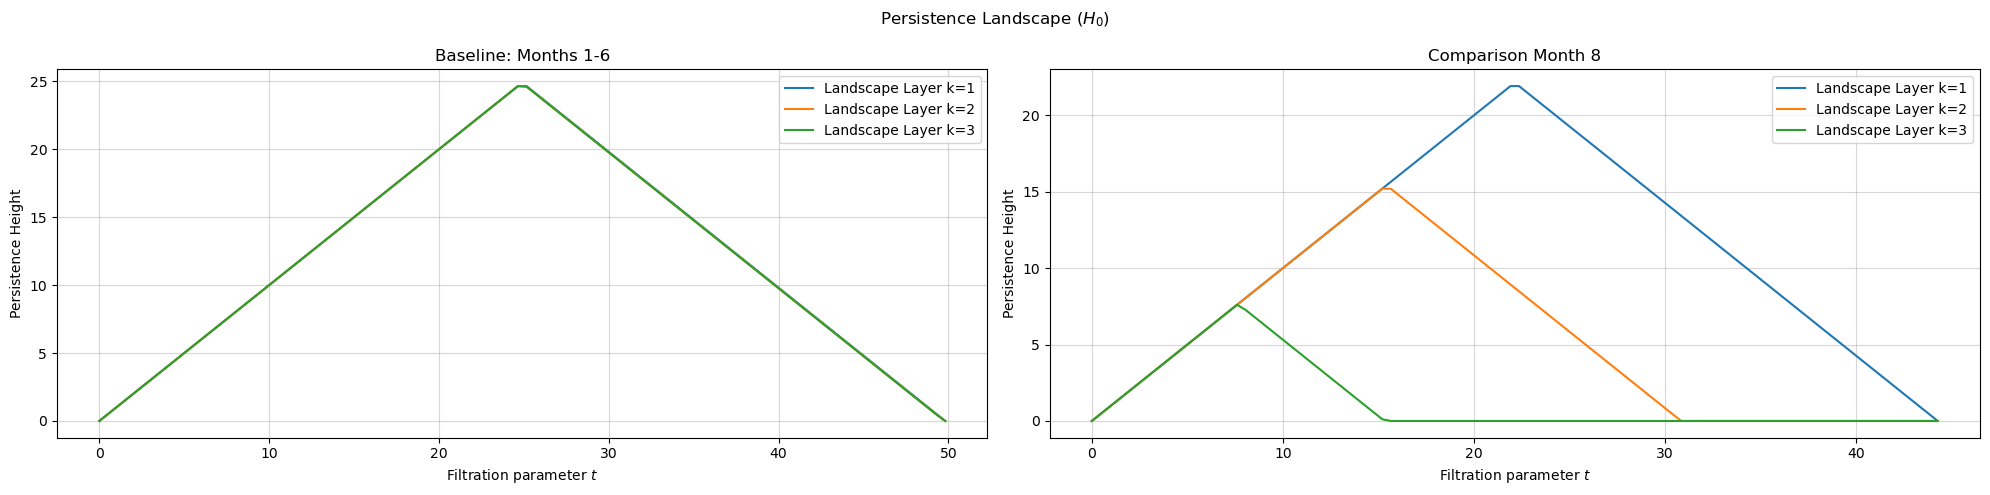

In [ ]:
# The homology dimension to build landscapes for
dim = 0
# The number of landscapes to build
num_landscapes = 3
# Number of evaluation points along filtration axis t
num_eval_points = 100


# Initialize plots
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle(f"Persistence Landscape ($H_{{{dim}}}$)", fontsize=12)

# ---------------------------------------------------------------------------------------------------------------

# Generate the persistence landscape for the baseline
t_vals_base, landscapes_base = persistence_landscape(
    persistence_pairs=birth_death_by_dimension_base,
    dim=dim,
    num_landscapes=num_landscapes,
    num_eval_points=num_eval_points,
)

# Plot the landscapes
for k in range(num_landscapes):
    ax[0].plot(t_vals_base, landscapes_base[k], label=f"Landscape Layer k={k+1}")

# Configure formatting for subplots
ax[0].set_title(f"Baseline: Months 1-6")
ax[0].set_xlabel("Filtration parameter $t$")
ax[0].set_ylabel("Persistence Height")
ax[0].grid(True, linestyle="-", alpha=0.5)
ax[0].legend()

# ---------------------------------------------------------------------------------------------------------------

# Generate the persistence landscape for the comparison month
t_vals_comp, landscapes_comp = persistence_landscape(
    persistence_pairs=birth_death_by_dimension_comp,
    dim=dim,
    num_landscapes=num_landscapes,
    num_eval_points=num_eval_points,
)

# Plot the landscapes
for k in range(num_landscapes):
    ax[1].plot(t_vals_comp, landscapes_comp[k], label=f"Landscape Layer k={k+1}")

# Configure formatting for subplots
ax[1].set_title(f"Comparison Month {comparison_month}")
ax[1].set_xlabel("Filtration parameter $t$")
ax[1].set_ylabel("Persistence Height")
ax[1].grid(True, linestyle="-", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

**Calculate distance between Baseline and Comparison landscape vectors:**

In addition to visually inspecting the peristence landscape plots, we can also calculate the distance between our Baseline and Comparison landscape vectorsin order to quantify the amount of structural shift in our feature space.

In [46]:
# Euclidean distance
vector_euclidean_dist = np.linalg.norm(landscapes_base - landscapes_comp)
print(f"Euclidean distance between persistence landscapes: {vector_euclidean_dist:.2f}")

Euclidean distance between persistence landscapes: 166.22
